In [ ]:
import numpy as np
import pandas as pd
import os

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from sklearn.model_selection import train_test_split
import random

drive_path = '/content/drive/MyDrive/Datasets/brain-tumor-mri-dataset'

all_images = []

for data_type in ['Training', 'Testing']:
    for tumor_type in ['notumor', 'pituitary', 'glioma', 'meningioma']:
        class_path = os.path.join(drive_path, data_type, tumor_type)
        class_images = [os.path.join(class_path, img) for img in os.listdir(class_path)]
        all_images.extend(class_images)

labels = [os.path.dirname(img).split(os.path.sep)[-1] for img in all_images]

train_images, test_images, train_labels, test_labels = train_test_split(
    all_images, labels, test_size=0.2, random_state=42, stratify=labels
)

def extract_labels(image_paths):
    return [os.path.dirname(img).split(os.path.sep)[-1] for img in image_paths]

X_train = train_images
Y_train = extract_labels(X_train)
X_test = test_images
Y_test = extract_labels(X_test)

print("Selected Training Images:", len(X_train))
print("Training Labels:", len(Y_train))
print("Selected Testing Images:", len(X_test))
print("Testing Labels:", len(Y_test))

Selected Training Images: 4579
Training Labels: 4579
Selected Testing Images: 1145
Testing Labels: 1145


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
def preprocess_images(image_paths, target_size=(224, 224)):
    images = []
    for img_path in image_paths:
        img = load_img(img_path, target_size=target_size)
        img_array = img_to_array(img)
        images.append(img_array)
    return np.array(images,dtype="float16")

In [ ]:
from sklearn.preprocessing import LabelEncoder

X_train_processed = preprocess_images(X_train)
X_test_processed = preprocess_images(X_test)

label_encoder = LabelEncoder()
Y_train = label_encoder.fit_transform(Y_train)
Y_test = label_encoder.transform(Y_test)

Y_train = np.array(Y_train)
Y_test = np.array(Y_test)

In [ ]:
tf.test.gpu_device_name()

'/device:GPU:0'

In [ ]:
!pip install shap --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.2/538.2 kB 9.8 MB/s eta 0:00:00


In [ ]:
import shap
import pickle
import matplotlib.pyplot as plt

In [ ]:
with open('/content/drive/MyDrive/FYP/Finalll/Iteration_1_model.pkl', 'rb') as file:
    model = pickle.load(file)

In [ ]:
predicted_labels = model.predict(X_test_processed).argmax(axis=1)

misclassified_indices = []

for i in range(len(Y_test)):
    if predicted_labels[i] != Y_test[i]:
        misclassified_indices.append(i)
print(misclassified_indices)

44/44 [==============================] - 6s 48ms/step
[53, 70, 74, 148, 157, 172, 194, 198, 204, 225, 251, 259, 298, 320, 335, 375, 424, 433, 463, 482, 483, 536, 537, 550, 566, 602, 617, 622, 624, 631, 666, 667, 694, 705, 718, 723, 728, 736, 755, 758, 760, 784, 802, 814, 872, 930, 945, 985, 1047, 1095, 1170, 1191, 1192, 1200, 1235, 1240, 1263, 1265, 1268, 1287, 1299, 1316, 1377, 1391]


In [ ]:
misclassified_image_index = misclassified_indices[0]
misclassified_image_path = all_images[misclassified_image_index]
print("Path of misclassified image:", misclassified_image_path)

Path of misclassified image: /content/drive/MyDrive/brain-tumor-mri-dataset/Training/notumor/Tr-no_0711.jpg


In [ ]:
misclassified_image = plt.imread(misclassified_image_path)

In [ ]:
import cv2
resized_img = cv2.resize(misclassified_image, (224, 224))
resized_imgs=[]
resized_imgs.append(resized_img)

In [ ]:
masker = shap.maskers.Image("inpaint_telea", (224,224,3))
misclassified_images = X_test_processed[misclassified_indices]
misclassified_images = np.array(misclassified_images)
misclassified_images = misclassified_images.astype("float32")
explainer = shap.Explainer(model, masker, output_names=["notumor", "pituitary", "glioma", "meningioma"])
shap_values = explainer(
    misclassified_images[0:1], max_evals=500, batch_size=50, outputs=shap.Explanation.argsort.flip[:1]
)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:14, 14.43s/it]               


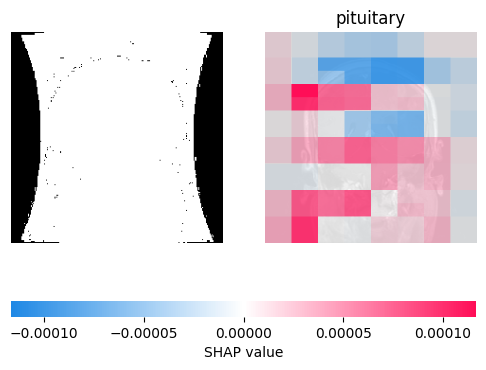

In [ ]:
shap.image_plot(shap_values)

In [ ]:
print(shap_values.shape)
print(type(shap_values))

(1, 224, 224, 3, 1)
<class 'shap._explanation.Explanation'>


In [ ]:
import pickle
with open('Iteration_1_model.pkl', 'rb') as file:
    retrained_model = pickle.load(file)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = '/content/image(98).jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

predictions = retrained_model.predict(img_array)

1/1 [==============================] - 3s 3s/step


In [ ]:
predicted_class_index = np.argmax(predictions[0])
class_names = ['notumor', 'pituitary', 'glioma', 'meningioma']
predicted_class = class_names[predicted_class_index]

print("Predicted class:", predicted_class)

actual_class_index = 0
actual_class = class_names[actual_class_index]

print("Actual class:", actual_class)

is_correct = predicted_class_index == actual_class_index
print("Is correct prediction:", is_correct)

Predicted class: notumor
Actual class: notumor
Is correct prediction: True


In [ ]:
retrained_model.save('model.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/FYP_CNN.h5')

In [ ]:
retrained_predicted_labels = retrained_model.predict(X_test_processed).argmax(axis=1)

44/44 [==============================] - 2s 34ms/step


In [ ]:
retrained_misclassified_indices = []

for i in range(len(Y_test)):
    if retrained_predicted_labels[i] != Y_test[i]:
        retrained_misclassified_indices.append(i)
print(retrained_misclassified_indices)

[226, 357, 728, 760, 771, 784, 1102, 1110, 1192, 1316, 1377]


In [ ]:
common_elements = set(misclassified_indices).intersection(retrained_misclassified_indices)
print(common_elements)

{1377, 1316, 1192, 760, 784, 728}


In [ ]:
retrained_explainer = shap.Explainer(retrained_model, masker, output_names=["notumor", "pituitary", "glioma", "meningioma"])
retrained_shap_values = retrained_explainer(
    misclassified_images[0:1], max_evals=500, batch_size=50, outputs=shap.Explanation.argsort.flip[:1]
)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:16, 16.77s/it]               


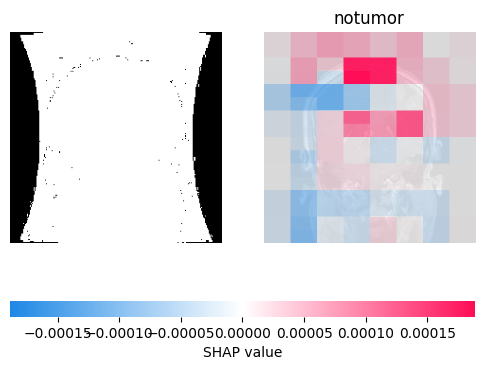

In [ ]:
shap.image_plot(retrained_shap_values)

In [ ]:
import os
import random
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
from IPython.display import Image
import imutils

# from sklearn.metrics import accuracy_score, confusion_matrix, plot_confusion_matrix, classification_report

import keras
import tensorflow.keras as K

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator, array_to_img, img_to_array
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Conv2D, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import imutils

In [ ]:
import keras

# Assuming 'model' is your Keras model


def VizGradCAM(model, image, interpolant=0.5, plot_results=True):

    """VizGradCAM - Displays GradCAM based on Keras / TensorFlow models
    using the gradients from the last convolutional layer. This function
    should work with all Keras Application listed here:
    https://keras.io/api/applications/
    Parameters:
    model (keras.model): Compiled Model with Weights Loaded
    image: Image to Perform Inference On
    plot_results (boolean): True - Function Plots using PLT
                            False - Returns Heatmap Array
    Returns:
    Heatmap Array?
    """
    #sanity check
    assert (interpolant > 0 and interpolant < 1), "Heatmap Interpolation Must Be Between 0 - 1"

    #STEP 1: Preprocesss image and make prediction using our model
    #input image
    original_img = np.asarray(image, dtype = np.float32)
    #expamd dimension and get batch size
    img = np.expand_dims(original_img, axis=0)
    #predict
    prediction = model.predict(img)
    #prediction index
    prediction_idx = np.argmax(prediction)

    #STEP 2: Create new model
    #specify last convolutional layer
    last_conv_layer = next(x for x in model.layers[::-1] if isinstance(x, keras.layers.Conv2D))
    target_layer = model.get_layer(last_conv_layer.name)

    #compute gradient of top predicted class
    with tf.GradientTape() as tape:
        #create a model with original model inputs and the last conv_layer as the output
        gradient_model = Model([model.inputs], [target_layer.output, model.output])
        #pass the image through the base model and get the feature map
        conv2d_out, prediction = gradient_model(img)
        #prediction loss
        loss = prediction[:, prediction_idx]

    #gradient() computes the gradient using operations recorded in context of this tape
    gradients = tape.gradient(loss, conv2d_out)

    #obtain the output from shape [1 x H x W x CHANNEL] -> [H x W x CHANNEL]
    output = conv2d_out[0]

    #obtain depthwise mean
    weights = tf.reduce_mean(gradients[0], axis=(0, 1))


    #create a 7x7 map for aggregation
    activation_map = np.zeros(output.shape[0:2], dtype=np.float32)
    #multiply weight for every layer
    for idx, weight in enumerate(weights):
        activation_map += weight * output[:, :, idx]
    #resize to image size
    activation_map = cv2.resize(activation_map.numpy(),
                                (original_img.shape[1],
                                 original_img.shape[0]))
    #ensure no negative number
    activation_map = np.maximum(activation_map, 0)
    #convert class activation map to 0 - 255
    activation_map = (activation_map - activation_map.min()) / (activation_map.max() - activation_map.min())
    #rescale and convert the type to int
    activation_map = np.uint8(255 * activation_map)


    #convert to heatmap
    heatmap = cv2.applyColorMap(activation_map, cv2.COLORMAP_JET)

    #superimpose heatmap onto image
    original_img = np.uint8((original_img - original_img.min()) / (original_img.max() - original_img.min()) * 255)
    cvt_heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    cvt_heatmap = img_to_array(cvt_heatmap)

    #enlarge plot
    plt.rcParams["figure.dpi"] = 100

    if plot_results == True:
        plt.imshow(np.uint8(original_img * interpolant + cvt_heatmap * (1 - interpolant)))
    else:
        return cvt_heatmap

In [ ]:
#load image
import cv2
from tensorflow.keras.preprocessing.image import load_img, ImageDataGenerator, array_to_img, img_to_array
# test_img = test_img.reshape(224,224,3)

from PIL import Image

# Open the image file
# test_img = cv2.imread()

image = Image.open("/content/drive/MyDrive/fyp_flask/static/images/Te-meTr_0008.jpg")

# Resize the image to (224, 224)
resized_image = image.resize((224, 224))

# Convert the image to numpy array and add batch dimension
# input_data = np.expand_dims(np.array(resized_image), axis=0)


# print(resized_image.shape)
#apply function
VizGradCAM(model, img_to_array(resized_image), plot_results=True)

1/1 [==============================] - 2s 2s/step


StopIteration: 